In [1]:
import sys
import numpy as np
import torch 

# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.2.1+cu118
11.8
2.2.1+cu118
11.8


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


In [75]:
# Import visulization tools from Leaflet-private 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/utils')
import visualization as vt 

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/LeafletLeaflet18mo_model_input.h5"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=10000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

print(final_data.head())


Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  51686
Number of junctions after removing singletons:  51686
The number of unique cell types in the data is:  7512
The number of unique cells in the data is:  7512
The number of unique junctions in the data is:  51687
The maximum junction count was initially:  513439
1029
The maximum junction count is now:  9999
The number of junctions in the data is:  47348
The number of cells in the data is:  7505
The number of cell types in the data is:  7505
The number of cells going into training data is:
7505
7505
   cell_id_index  junction_id_index  junc_count  cluster_count  clustminjunc  \
0              0                  0        20.0             20           0.0   
1              0                  1       105.0            143          38.0   
2              0                  2        38.0            143         105.0   
3              0          

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [5]:
# metadata file
metadata = "/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/metadata/tabula-muris-senis-full-metadata.csv"
metadata = pd.read_csv(metadata)
metadata = metadata[metadata['method'] == 'facs']
brain_only = metadata[metadata['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]
brain_only['cell_id'] = brain_only['index'].str.split('.').str[0]
brain_only.head()

/scratch/ipykernel_264235/1577861364.py:3: DtypeWarning: Columns (3,5,14) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata)
/scratch/ipykernel_264235/1577861364.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_only['cell_id'] = brain_only['index'].str.split('.').str[0]


,index,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden,cell_id
245979,C4_B001059_B009342_S52.mm10-plus-0-0-1,18m,1,NaN,oligodendrocyte,NaN,NaN,facs,18_46_F,53318960.0,2754.0,female,Striatum,Brain_Non-Myeloid,NaN,30,32,C4_B001059_B009342_S52
246263,E10_B001059_B009342_S106.mm10-plus-0-0-1,18m,1,NaN,oligodendrocyte,NaN,NaN,facs,18_46_F,8817765.0,2701.0,female,Striatum,Brain_Non-Myeloid,NaN,30,32,E10_B001059_B009342_S106
246404,E22_B001059_B009342_S118.mm10-plus-0-0-1,18m,1,NaN,"CD8-positive, alpha-beta T cell",NaN,NaN,facs,18_46_F,3267464.0,1969.0,female,Striatum,Brain_Non-Myeloid,NaN,4,9,E22_B001059_B009342_S118
246673,F5_B001059_B009342_S125.mm10-plus-0-0-1,18m,1,NaN,oligodendrocyte,NaN,NaN,facs,18_46_F,31601110.0,1542.0,female,Striatum,Brain_Non-Myeloid,NaN,30,32,F5_B001059_B009342_S125
246814,G18_B001059_B009342_S162.mm10-plus-0-0-1,18m,1,NaN,microglial cell,NaN,NaN,facs,18_46_F,75163.0,605.0,female,Striatum,Brain_Non-Myeloid,NaN,15,17,G18_B001059_B009342_S162


In [6]:
# remove the cell_type column from final_data 
final_data.drop(columns=["cell_type"], inplace=True)

In [7]:
brain_only = brain_only[["cell_id", "cell_ontology_class"]]
# rename column cell_ontology_class to cell_type 
brain_only = brain_only.rename(columns={"cell_ontology_class": "cell_type"})
brain_only.head()

,cell_id,cell_type
245979,C4_B001059_B009342_S52,oligodendrocyte
246263,E10_B001059_B009342_S106,oligodendrocyte
246404,E22_B001059_B009342_S118,"CD8-positive, alpha-beta T cell"
246673,F5_B001059_B009342_S125,oligodendrocyte
246814,G18_B001059_B009342_S162,microglial cell


In [8]:
# merge brain_only with final_data by cell_id 
final_data = pd.merge(final_data, brain_only, on="cell_id", how="left")

In [9]:
# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

The number of junctions is:  47348
The number of intron clusters observed is:  14318
The number of genes is:  8864
The number of cells is:  7505


In [10]:
cell_types = simple_data["cell_type"].unique()
print(cell_types)

['endothelial cell' 'microglial cell' 'brain pericyte' 'astrocyte'
 'macrophage' 'oligodendrocyte' 'interneuron' 'neuron'
 'CD8-positive, alpha-beta T cell' 'medium spiny neuron'
 'oligodendrocyte precursor cell' 'Bergmann glial cell'
 'neuronal stem cell' 'neuroepithelial cell' 'T cell' 'mature NK T cell'
 'ependymal cell']


In [11]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [12]:
# how many junctions are detected per cell, how many intron clusters in cell?, how many genes in cell? how many total junction read counts in a given cell? 
junctions_per_cell = simple_data.groupby("cell_id_index").size()
clusters_per_cell = simple_data.groupby("cell_id_index").Cluster.nunique()
genes_per_cell = simple_data.groupby("cell_id_index").gene_id.nunique()
total_junction_counts_per_cell = simple_data.groupby("cell_id_index").junc_count.sum()
average_junction_counts_per_cell = simple_data.groupby("cell_id_index").junc_count.mean()

# convert each to a dataframe with proper column names
junctions_per_cell = junctions_per_cell.to_frame(name="junctions_per_cell")
clusters_per_cell = clusters_per_cell.to_frame(name="clusters_per_cell")
genes_per_cell = genes_per_cell.to_frame(name="genes_per_cell")
total_junction_counts_per_cell = total_junction_counts_per_cell.to_frame(name="total_junction_counts_per_cell")
average_junction_counts_per_cell = average_junction_counts_per_cell.to_frame(name="average_junction_counts_per_cell")

# make sure they all have cell_id_index column also
junctions_per_cell["cell_id_index"] = junctions_per_cell.index
clusters_per_cell["cell_id_index"] = clusters_per_cell.index
genes_per_cell["cell_id_index"] = genes_per_cell.index
total_junction_counts_per_cell["cell_id_index"] = total_junction_counts_per_cell.index
average_junction_counts_per_cell["cell_id_index"] = average_junction_counts_per_cell.index

# remove index name 
junctions_per_cell.index.name = None
clusters_per_cell.index.name = None
genes_per_cell.index.name = None
total_junction_counts_per_cell.index.name = None
average_junction_counts_per_cell.index.name = None

In [13]:
cell_ids_conversion = cell_ids_conversion.merge(junctions_per_cell, on="cell_id_index").merge(clusters_per_cell, on="cell_id_index").merge(genes_per_cell, on="cell_id_index").merge(total_junction_counts_per_cell, on="cell_id_index").merge(average_junction_counts_per_cell, on="cell_id_index")

In [14]:
tot_clusters = simple_data.Cluster.nunique()
tot_genes = simple_data.gene_id.nunique()
tot_junctions = simple_data.junction_id_index.nunique()

cell_ids_conversion["perc_juncs"] = cell_ids_conversion.junctions_per_cell / tot_junctions
cell_ids_conversion["perc_clusters"] = cell_ids_conversion.clusters_per_cell / tot_clusters
cell_ids_conversion["perc_genes"] = cell_ids_conversion.genes_per_cell / tot_genes
cell_ids_conversion.head()

,cell_id_index,cell_id,cell_type,junctions_per_cell,clusters_per_cell,genes_per_cell,total_junction_counts_per_cell,average_junction_counts_per_cell,perc_juncs,perc_clusters,perc_genes
0,0,A10_B000176_B008056_S10,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1042,325,269,39751.0,38.148752,0.022007,0.022699,0.030347
1,1,A10_B001060_B009250_S214,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1363,436,331,13420.0,9.845928,0.028787,0.030451,0.037342
2,2,A10_B001061_B009251_S298,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1761,549,437,17069.0,9.692788,0.037193,0.038343,0.049301
3,3,A10_B001244_B006737_S10,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,2019,645,500,79807.0,39.527984,0.042642,0.045048,0.056408
4,4,A10_B001354_B006743_S10,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,3422,1039,804,20560.0,6.008182,0.072273,0.072566,0.090704


In [15]:
# remove cell_type column from cell_ids_conversion 
cell_ids_conversion.drop(columns=["cell_type"], inplace=True)
cell_ids_conversion = pd.merge(cell_ids_conversion, brain_only, on="cell_id", how="left")
cell_ids_conversion

,cell_id_index,cell_id,junctions_per_cell,clusters_per_cell,genes_per_cell,total_junction_counts_per_cell,average_junction_counts_per_cell,perc_juncs,perc_clusters,perc_genes,cell_type
0,0,A10_B000176_B008056_S10,1042,325,269,39751.0,38.148752,0.022007,0.022699,0.030347,endothelial cell
1,1,A10_B001060_B009250_S214,1363,436,331,13420.0,9.845928,0.028787,0.030451,0.037342,microglial cell
2,2,A10_B001061_B009251_S298,1761,549,437,17069.0,9.692788,0.037193,0.038343,0.049301,microglial cell
3,3,A10_B001244_B006737_S10,2019,645,500,79807.0,39.527984,0.042642,0.045048,0.056408,microglial cell
4,4,A10_B001354_B006743_S10,3422,1039,804,20560.0,6.008182,0.072273,0.072566,0.090704,microglial cell
...,...,...,...,...,...,...,...,...,...,...,...
7500,7500,P9_B002705_B008594_S369,1569,482,374,106966.0,68.174634,0.033138,0.033664,0.042193,microglial cell
7501,7501,P9_D045315_B008285_S369,1693,542,396,32101.0,18.961016,0.035757,0.037854,0.044675,microglial cell
7502,7502,P9_D045318_B008591_S369,2002,642,492,42187.0,21.072428,0.042283,0.044839,0.055505,microglial cell
7503,7503,P9_D045372_B009292_S177,229,71,70,294.0,1.283843,0.004837,0.004959,0.007897,neuroepithelial cell


In [16]:
# for each unique cell_type, plot the distribution of junctions_per_cell, clusters_per_cell, genes_per_cell, total_junction_counts_per_cell
import matplotlib.pyplot as plt

# save all plots into one pdf, cell_type per page
from matplotlib.backends.backend_pdf import PdfPages

# Create a single PDF object for all plots
with PdfPages("TS_Leaflet_cell_type_distributions_percentages.pdf") as pdf:
    for cell_type in cell_ids_conversion.cell_type.unique():
        cell_type_data = cell_ids_conversion[cell_ids_conversion.cell_type == cell_type]
        print("The number of cells in the tissue ", cell_type, " is: ", len(cell_type_data))

        # Prep plot for three horizontal subplots
        fig, axs = plt.subplots(1, 3, figsize=(10, 6))
        fig.suptitle(cell_type, size=6)

        # Reduce x-axis tick mark size for all subplots
        for ax in axs.flat:
            ax.tick_params(axis='x', labelsize=6)
            ax.set_xlabel(ax.get_xlabel(), fontsize=6)
            ax.tick_params(axis='y', labelsize=6)
            ax.set_ylabel(ax.get_ylabel(), fontsize=6)

        # Plot distributions and mark mean and median lines
        sns.ecdfplot(data=cell_type_data, x="perc_juncs", ax=axs[0])
        axs[0].set_title("perc_juncs", size=6)
        axs[0].axvline(cell_type_data["perc_juncs"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0].axvline(cell_type_data["perc_juncs"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="perc_clusters", ax=axs[1])
        axs[1].set_title("perc_clusters", size=6)
        axs[1].axvline(cell_type_data["perc_clusters"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1].axvline(cell_type_data["perc_clusters"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="perc_genes", ax=axs[2])
        axs[2].set_title("perc_genes", size=6)
        axs[2].axvline(cell_type_data["perc_genes"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[2].axvline(cell_type_data["perc_genes"].median(), color='g', linestyle='dashed', linewidth=2)
        
        # Save plot to PDF
        pdf.savefig(fig)
        plt.close(fig)

The number of cells in the tissue  endothelial cell  is:  1358
The number of cells in the tissue  microglial cell  is:  4511
The number of cells in the tissue  brain pericyte  is:  265
The number of cells in the tissue  astrocyte  is:  107
The number of cells in the tissue  macrophage  is:  86
The number of cells in the tissue  oligodendrocyte  is:  564
The number of cells in the tissue  interneuron  is:  98
The number of cells in the tissue  neuron  is:  123
The number of cells in the tissue  CD8-positive, alpha-beta T cell  is:  56
The number of cells in the tissue  medium spiny neuron  is:  11
The number of cells in the tissue  oligodendrocyte precursor cell  is:  94
The number of cells in the tissue  Bergmann glial cell  is:  14
The number of cells in the tissue  neuronal stem cell  is:  12
The number of cells in the tissue  neuroepithelial cell  is:  133
The number of cells in the tissue  T cell  is:  30
The number of cells in the tissue  mature NK T cell  is:  4
The number of cel

In [17]:
# Create a single PDF object for all plots
with PdfPages("TS_Leaflet_cell_type_distributions_counts.pdf") as pdf:
    for cell_type in cell_ids_conversion.cell_type.unique():
        cell_type_data = cell_ids_conversion[cell_ids_conversion.cell_type == cell_type]
        print("The number of cells in the tissue ", cell_type, " is: ", len(cell_type_data))

        # Use ecdf to plot the distribution of various parameters for each cell type
        fig, axs = plt.subplots(2, 2, figsize=(15, 8))
        fig.suptitle(cell_type, size=6)

        # Reduce x-axis tick mark size for all subplots
        for ax in axs.flat:
            ax.tick_params(axis='x', labelsize=6)
            ax.set_xlabel(ax.get_xlabel(), fontsize=6)
            ax.tick_params(axis='y', labelsize=6)
            ax.set_ylabel(ax.get_ylabel(), fontsize=6)

        # Plot distributions and mark mean and median lines
        sns.ecdfplot(data=cell_type_data, x="junctions_per_cell", ax=axs[0, 0])
        axs[0, 0].set_title("junctions_per_cell", size=6)
        axs[0, 0].axvline(cell_type_data["junctions_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0, 0].axvline(cell_type_data["junctions_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="clusters_per_cell", ax=axs[0, 1])
        axs[0, 1].set_title("clusters_per_cell", size=6)
        axs[0, 1].axvline(cell_type_data["clusters_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[0, 1].axvline(cell_type_data["clusters_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="genes_per_cell", ax=axs[1, 0])
        axs[1, 0].set_title("genes_per_cell", size=6)
        axs[1, 0].axvline(cell_type_data["genes_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1, 0].axvline(cell_type_data["genes_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        sns.ecdfplot(data=cell_type_data, x="total_junction_counts_per_cell", ax=axs[1, 1])
        axs[1, 1].set_title("total_junction_counts_per_cell", size=6)
        axs[1, 1].axvline(cell_type_data["total_junction_counts_per_cell"].mean(), color='r', linestyle='dashed', linewidth=2)
        axs[1, 1].axvline(cell_type_data["total_junction_counts_per_cell"].median(), color='g', linestyle='dashed', linewidth=2)

        # Save plot to PDF
        pdf.savefig(fig)
        plt.close(fig)

The number of cells in the tissue  endothelial cell  is:  1358
The number of cells in the tissue  microglial cell  is:  4511
The number of cells in the tissue  brain pericyte  is:  265
The number of cells in the tissue  astrocyte  is:  107
The number of cells in the tissue  macrophage  is:  86
The number of cells in the tissue  oligodendrocyte  is:  564
The number of cells in the tissue  interneuron  is:  98
The number of cells in the tissue  neuron  is:  123
The number of cells in the tissue  CD8-positive, alpha-beta T cell  is:  56
The number of cells in the tissue  medium spiny neuron  is:  11
The number of cells in the tissue  oligodendrocyte precursor cell  is:  94
The number of cells in the tissue  Bergmann glial cell  is:  14
The number of cells in the tissue  neuronal stem cell  is:  12
The number of cells in the tissue  neuroepithelial cell  is:  133
The number of cells in the tissue  T cell  is:  30
The number of cells in the tissue  mature NK T cell  is:  4
The number of cel

### Get ready for model training 

In [18]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [19]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [20]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [21]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [22]:
cluster_counts

<7505x47348 sparse matrix of type '<class 'numpy.int64'>'
	with 14300727 stored elements in COOrdinate format>

In [23]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.9597555700102948


## Run full factor model! 

In [24]:
reload(factor_model)

2.2.1+cu118
11.8


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Not using priors on a and b, running simpler non-hierarchical version!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 3637
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0612e+09, dtype=torch.float64)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0608e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
Epoch 0, Elbo loss: 1068452850.134306
The input_conc is:  tensor(inf)
input_conc 

/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(hyperparam, dtype=torch.float32)


tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0539e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0471e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0402e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0335e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0266e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0200e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.0135e+09, dtype=torch.float

Elbo loss: 217008268.09654877


The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-2.1335e+08, dtype=torch.float64, grad_fn=<SumBackward0>)


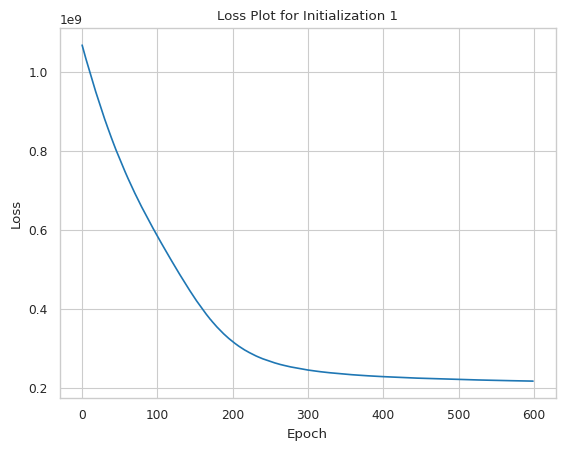

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 3369
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.9566e+09, dtype=torch.float64)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.9537e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
Epoch 0, Elbo loss: 1961843211.647016
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.9442e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.9345e+09, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-1.9

Elbo loss: 228616337.02491686


The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-2.2463e+08, dtype=torch.float64, grad_fn=<SumBackward0>)
The input_conc is:  tensor(inf)
input_conc tensor(inf)
input_conc tensor(inf)
log_probs tensor(-2.2459e+08, dtype=torch.float64, grad_fn=<SumBackward0>)


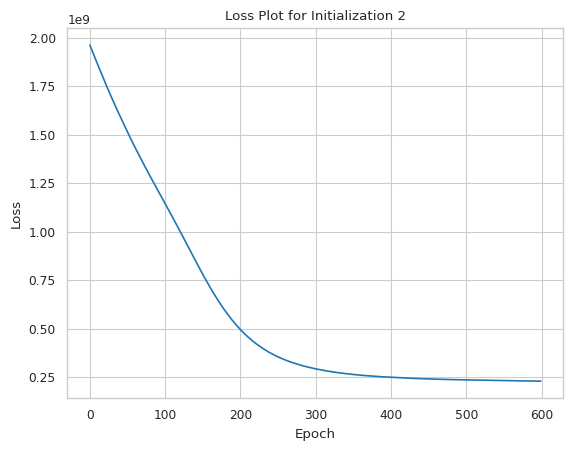

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [58]:
best_K = 50
K = best_K

# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)

# import torch.distributions as dist
# input_conc = dist.Gamma(concentration=2.0, rate=2.0)

#input_conc = 1
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=False, input_conc=input_conc, K=K, lr=0.01, loss_plot=True, num_epochs=600, save_to_file = False)

In [59]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))

1.5188959
2.1607096
The inferred concentration parameter is: 14.59823
The inferred pi parameter is: [0.29746386 0.01300875 0.01339214 0.01404958 0.18582985 0.05885339
 0.00995121 0.00971439 0.03308846 0.00989691 0.01150528 0.02237195
 0.01069335 0.00898081 0.0089591  0.01958172 0.00811997 0.00838058
 0.01500628 0.00930142 0.00784884 0.00783461 0.00955577 0.00951766
 0.01017981 0.0125165  0.00753162 0.01061326 0.00696773 0.00723106
 0.0078151  0.00708868 0.00729582 0.00718195 0.00712899 0.00992023
 0.00907428 0.00690853 0.00696673 0.00785737 0.00676962 0.00643081
 0.00645397 0.00726383 0.00696666 0.00688585 0.00595155 0.00648369
 0.00575785 0.00585262]


### Evaluate latent variables 

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


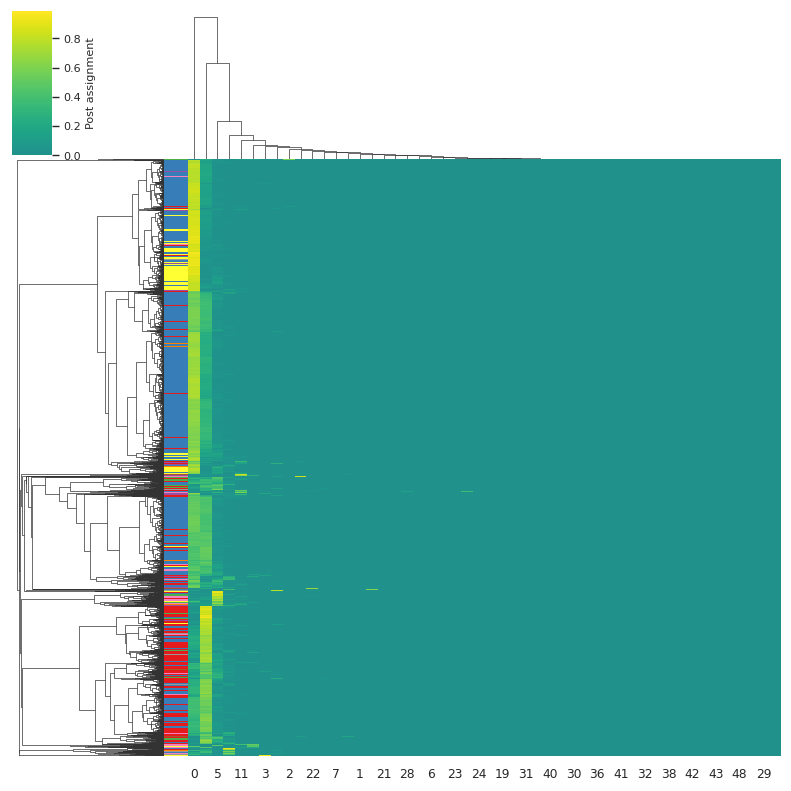

In [60]:
import seaborn as sns

color_palette = sns.color_palette("tab20", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [61]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

The silhouette score for K = 50 is: -0.0727847
The Davies Bouldin score for K = 50 is: 7.127212880303761


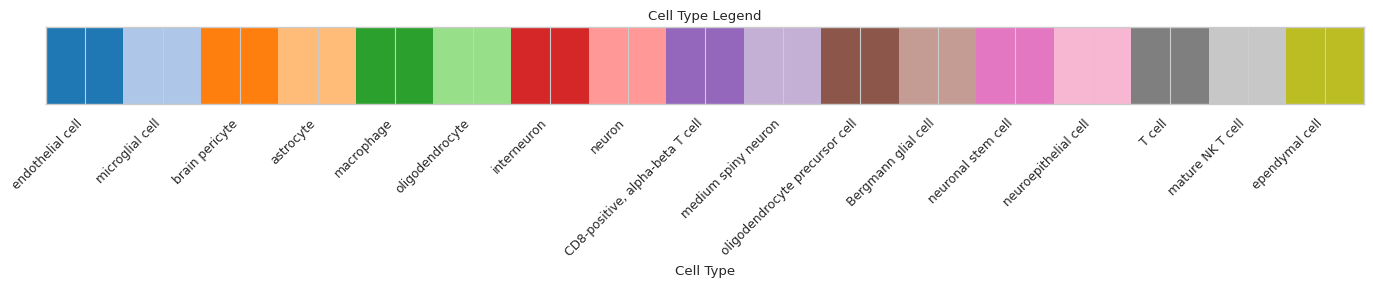

In [62]:
# print cell type color legend seperately
import matplotlib.pyplot as plt

cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [63]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

/scratch/ipykernel_264235/177290916.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

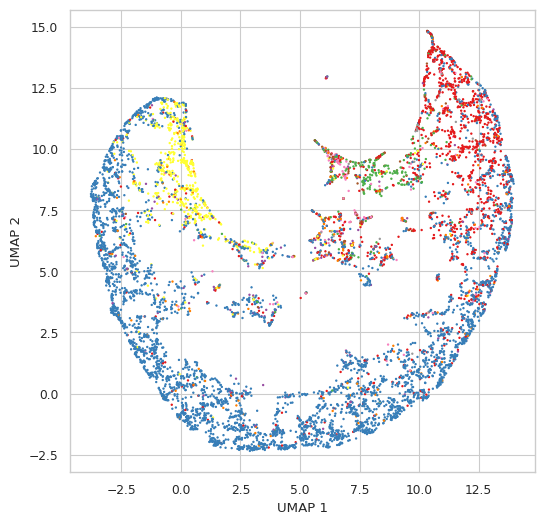

In [64]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

[0.6584909  0.18965946 0.05387715 0.02948707 0.01633109 0.01106665
 0.00944351 0.00620658 0.00478581 0.00390826]


/scratch/ipykernel_264235/2178371379.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

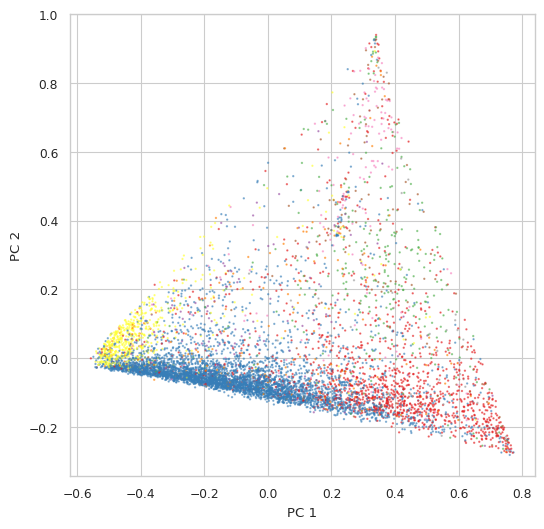

In [65]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

import pandas as pd

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [66]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,...,Factor 40,Factor 41,Factor 42,Factor 43,Factor 44,Factor 45,Factor 46,Factor 47,Factor 48,Factor 49
endothelial cell,0.259293,0.001484,0.001346,0.005747,0.541284,0.104165,0.000631,0.000291,0.041921,0.000231,...,0.000038,0.000017,0.000017,0.000035,0.000028,0.000019,0.000007,0.000012,0.000003,0.000003
microglial cell,0.605160,0.000990,0.000731,0.001783,0.303466,0.045585,0.000167,0.000704,0.020345,0.000716,...,0.000019,0.000016,0.000015,0.000017,0.000018,0.000017,0.000006,0.000012,0.000004,0.000004
brain pericyte,0.160944,0.000897,0.000856,0.001753,0.380299,0.340213,0.000172,0.000348,0.079229,0.000181,...,0.000043,0.000024,0.000012,0.000021,0.000015,0.000015,0.000004,0.000007,0.000004,0.000004
astrocyte,0.497786,0.000799,0.008572,0.020546,0.197353,0.086365,0.000354,0.008268,0.037381,0.000240,...,0.000030,0.000019,0.000014,0.000029,0.000023,0.000013,0.000005,0.000013,0.000005,0.000003
macrophage,0.469229,0.000795,0.000506,0.013157,0.384793,0.080392,0.000091,0.000160,0.030402,0.000370,...,0.000027,0.000009,0.000008,0.000017,0.000009,0.000030,0.000003,0.000012,0.000002,0.000005
oligodendrocyte,0.809213,0.000226,0.000879,0.002391,0.044536,0.074245,0.000198,0.000130,0.029784,0.000113,...,0.000024,0.000009,0.000011,0.000018,0.000026,0.000019,0.000002,0.000014,0.000003,0.000002
interneuron,0.075381,0.001639,0.026984,0.010227,0.237100,0.256214,0.000433,0.005039,0.057912,0.001098,...,0.000037,0.000018,0.000016,0.000025,0.000034,0.000045,0.000010,0.000020,0.000008,0.000006
neuron,0.129778,0.000739,0.016737,0.001940,0.139851,0.368281,0.000497,0.000504,0.064251,0.000504,...,0.000060,0.000026,0.000022,0.000070,0.000213,0.000048,0.000030,0.000053,0.000007,0.000015
"CD8-positive, alpha-beta T cell",0.191271,0.001477,0.000704,0.003553,0.505004,0.135726,0.000244,0.000342,0.087262,0.000154,...,0.000010,0.000010,0.000025,0.000015,0.000044,0.000022,0.000006,0.000025,0.000003,0.000006
medium spiny neuron,0.017001,0.000437,0.001033,0.000455,0.145569,0.661991,0.000169,0.000187,0.032811,0.000207,...,0.000028,0.000006,0.000004,0.000042,0.000023,0.000027,0.000001,0.000014,0.000003,0.000002


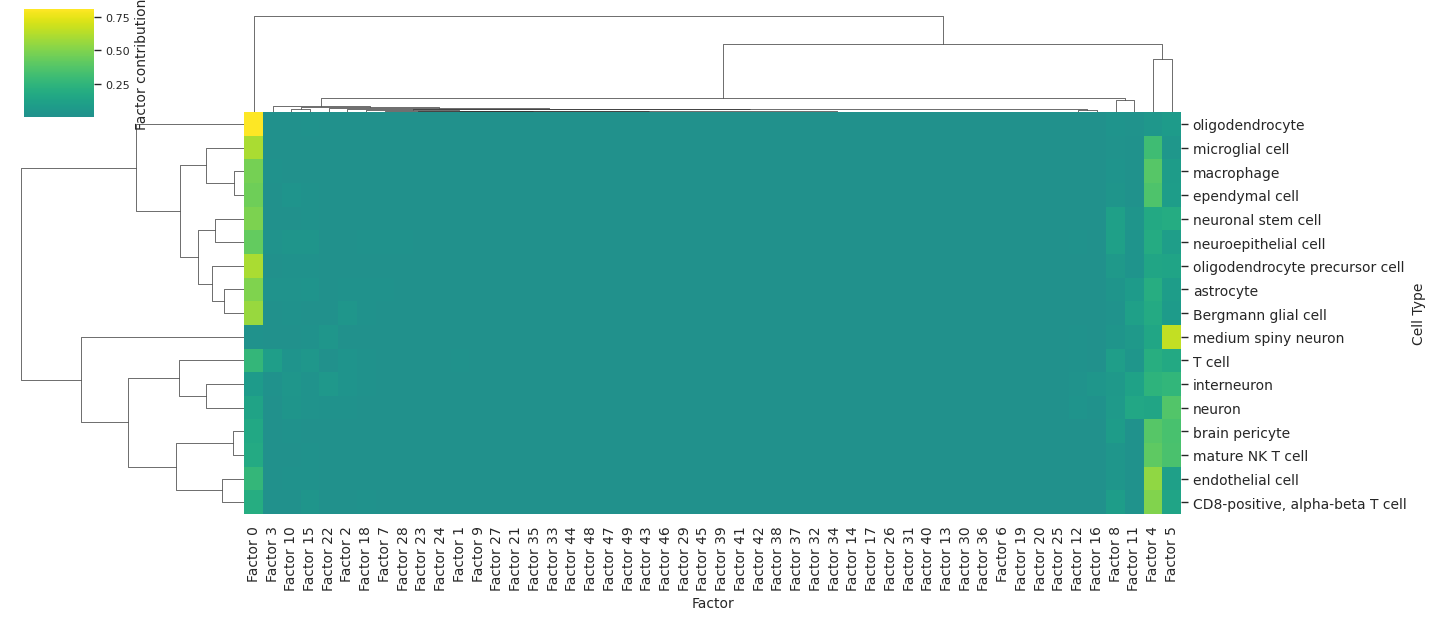

In [67]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(14, 6),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )
# increase font of everything 
cluster.ax_heatmap.tick_params(labelsize=10)
cluster.ax_heatmap.set_xlabel('Factor', size=10)
cluster.ax_heatmap.set_ylabel('Cell Type', size=10)
cluster.cax.set_ylabel('Factor contribution', size=10)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [68]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

array([0.29746386, 0.01300875, 0.01339214, 0.01404958, 0.18582985,
       0.05885339, 0.00995121, 0.00971439, 0.03308846, 0.00989691,
       0.01150528, 0.02237195, 0.01069335, 0.00898081, 0.0089591 ,
       0.01958172, 0.00811997, 0.00838058, 0.01500628, 0.00930142,
       0.00784884, 0.00783461, 0.00955577, 0.00951766, 0.01017981,
       0.0125165 , 0.00753162, 0.01061326, 0.00696773, 0.00723106,
       0.0078151 , 0.00708868, 0.00729582, 0.00718195, 0.00712899,
       0.00992023, 0.00907428, 0.00690853, 0.00696673, 0.00785737,
       0.00676962, 0.00643081, 0.00645397, 0.00726383, 0.00696666,
       0.00688585, 0.00595155, 0.00648369, 0.00575785, 0.00585262],
      dtype=float32)

          pi     Factor
0   0.297464   Facotor0
4   0.185830   Facotor4
5   0.058853   Facotor5
8   0.033088   Facotor8
11  0.022372  Facotor11


/scratch/ipykernel_264235/3902371712.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

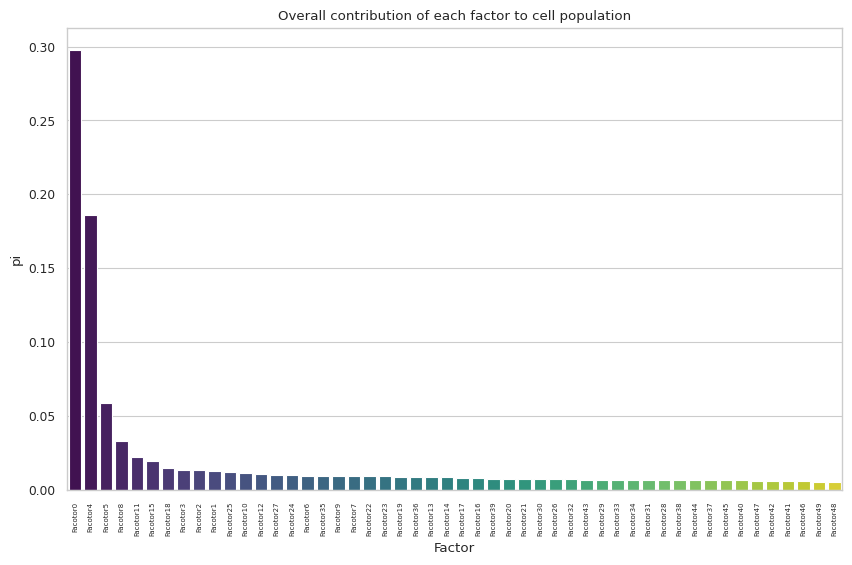

In [69]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")


Text(0.5, 0, 'Factor contribution')

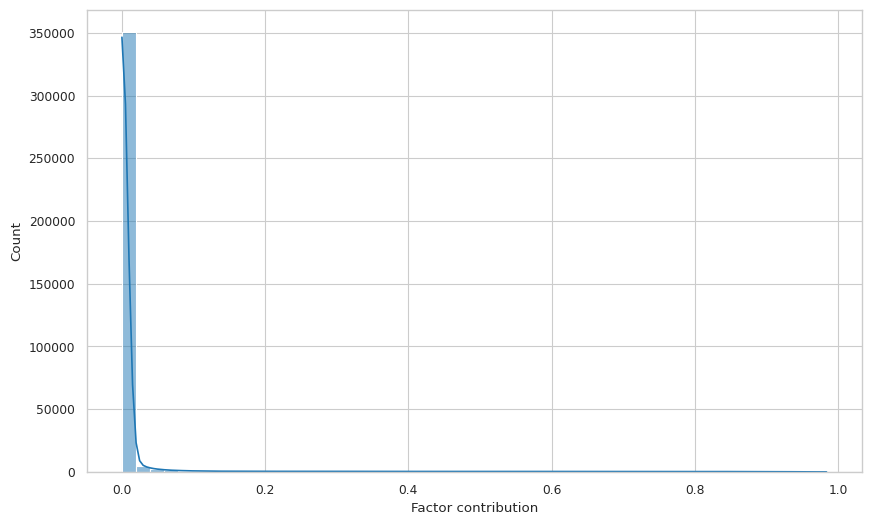

In [71]:
# make histogram of the values in assign_post
plt.figure(figsize=(10, 6))
sns.histplot(assign_post.flatten(), bins=50, kde=True)
plt.xlabel("Factor contribution")

In [88]:
# convert psis to df 
psis_df = pd.DataFrame(psis)
psis_df.head()

,0,1,2,3,4,5,6,7,8,9,...,47338,47339,47340,47341,47342,47343,47344,47345,47346,47347
0,0.995399,0.491789,0.014378,0.989895,0.973472,0.515599,0.776532,0.728084,0.619854,0.386568,...,0.018144,0.012375,0.005627,0.394645,0.038524,0.023404,0.004832,0.077712,0.084343,0.017511
1,0.818226,0.804524,0.499206,0.881434,0.800823,0.831980,0.843313,0.656852,0.644804,0.455596,...,0.266645,0.258732,0.255278,0.534310,0.313780,0.095784,0.195564,0.223196,0.392274,0.284663
2,0.931991,0.747260,0.262015,0.865660,0.870399,0.980274,0.548045,0.661745,0.378130,0.552629,...,0.346259,0.466963,0.276264,0.554843,0.186636,0.475151,0.305431,0.173584,0.277831,0.462870
3,0.821692,0.926710,0.177875,0.862522,0.966420,0.921910,0.877037,0.809282,0.042125,0.183469,...,0.467520,0.482543,0.157008,0.497260,0.386010,0.672934,0.188504,0.284988,0.215089,0.245496
4,0.977919,0.484719,0.029374,0.991042,0.920464,0.634375,0.994165,0.755362,0.602738,0.366250,...,0.009884,0.016646,0.013075,0.197085,0.019327,0.031150,0.027625,0.019044,0.023823,0.015639


In [91]:
psis_df = psis_df.T

In [92]:
psis_df

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.995399,0.818226,0.931991,0.821692,0.977919,0.971918,0.755127,0.940805,0.978759,0.816516,...,0.935214,0.883356,0.759435,0.852421,0.785408,0.789123,0.712452,0.809704,0.871681,0.771611
1,0.491789,0.804524,0.747260,0.926710,0.484719,0.567311,0.365574,0.406164,0.574150,0.621811,...,0.513098,0.542100,0.451864,0.399152,0.364814,0.488321,0.368205,0.666135,0.555257,0.496051
2,0.014378,0.499206,0.262015,0.177875,0.029374,0.028852,0.251570,0.426713,0.050217,0.235042,...,0.305392,0.411868,0.565620,0.186680,0.351327,0.262078,0.382927,0.231481,0.321644,0.635587
3,0.989895,0.881434,0.865660,0.862522,0.991042,0.975521,0.699176,0.817002,0.959193,0.824461,...,0.833536,0.871808,0.719019,0.779181,0.852521,0.814920,0.804737,0.726543,0.851210,0.833111
4,0.973472,0.800823,0.870399,0.966420,0.920464,0.980857,0.655218,0.821568,0.946505,0.879820,...,0.893499,0.740562,0.748622,0.679960,0.837399,0.734467,0.683816,0.842938,0.802917,0.768047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47343,0.023404,0.095784,0.475151,0.672934,0.031150,0.069868,0.277080,0.376626,0.045444,0.458942,...,0.149756,0.814956,0.234892,0.271059,0.211234,0.212814,0.849723,0.135124,0.301766,0.492838
47344,0.004832,0.195564,0.305431,0.188504,0.027625,0.029174,0.391081,0.409213,0.033960,0.376136,...,0.282380,0.347090,0.498738,0.259120,0.383162,0.295187,0.392208,0.368489,0.540323,0.407063
47345,0.077712,0.223196,0.173584,0.284988,0.019044,0.060244,0.396852,0.759125,0.209660,0.339447,...,0.586599,0.734181,0.200767,0.209058,0.101058,0.492249,0.508353,0.885777,0.712391,0.576829
47346,0.084343,0.392274,0.277831,0.215089,0.023823,0.120354,0.526816,0.361986,0.054481,0.225430,...,0.077331,0.745494,0.241578,0.385993,0.705985,0.325950,0.243311,0.731265,0.242728,0.726795


In [93]:
# add column summarizing variance of each row 
psis_df["var"] = psis_df.var(axis=1)
psis_df.head()

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,var
0,0.995399,0.818226,0.931991,0.821692,0.977919,0.971918,0.755127,0.940805,0.978759,0.816516,...,0.883356,0.759435,0.852421,0.785408,0.789123,0.712452,0.809704,0.871681,0.771611,0.005824
1,0.491789,0.804524,0.747260,0.926710,0.484719,0.567311,0.365574,0.406164,0.574150,0.621811,...,0.542100,0.451864,0.399152,0.364814,0.488321,0.368205,0.666135,0.555257,0.496051,0.025373
2,0.014378,0.499206,0.262015,0.177875,0.029374,0.028852,0.251570,0.426713,0.050217,0.235042,...,0.411868,0.565620,0.186680,0.351327,0.262078,0.382927,0.231481,0.321644,0.635587,0.019096
3,0.989895,0.881434,0.865660,0.862522,0.991042,0.975521,0.699176,0.817002,0.959193,0.824461,...,0.871808,0.719019,0.779181,0.852521,0.814920,0.804737,0.726543,0.851210,0.833111,0.005200
4,0.973472,0.800823,0.870399,0.966420,0.920464,0.980857,0.655218,0.821568,0.946505,0.879820,...,0.740562,0.748622,0.679960,0.837399,0.734467,0.683816,0.842938,0.802917,0.768047,0.007823


In [96]:
psis_df["junction_id_index"] = range(psis_df.shape[0])

In [97]:
# add junction_ids_conversion info to psis_df 
psis_df = psis_df.merge(junction_ids_conversion, on="junction_id_index", how="left")
psis_df

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,var,junction_id_index,junction_id,Cluster,gene_id
0,0.995399,0.818226,0.931991,0.821692,0.977919,0.971918,0.755127,0.940805,0.978759,0.816516,...,0.789123,0.712452,0.809704,0.871681,0.771611,0.005824,0,1_63177291_63177753,149,ENSMUSG00000025967.16
1,0.491789,0.804524,0.747260,0.926710,0.484719,0.567311,0.365574,0.406164,0.574150,0.621811,...,0.488321,0.368205,0.666135,0.555257,0.496051,0.025373,1,1_37430282_37431292,242,ENSMUSG00000026111.15
2,0.014378,0.499206,0.262015,0.177875,0.029374,0.028852,0.251570,0.426713,0.050217,0.235042,...,0.262078,0.382927,0.231481,0.321644,0.635587,0.019096,2,1_37430493_37431296,242,ENSMUSG00000026111.15
3,0.989895,0.881434,0.865660,0.862522,0.991042,0.975521,0.699176,0.817002,0.959193,0.824461,...,0.814920,0.804737,0.726543,0.851210,0.833111,0.005200,3,1_75171048_75171235,378,ENSMUSG00000026197.12
4,0.973472,0.800823,0.870399,0.966420,0.920464,0.980857,0.655218,0.821568,0.946505,0.879820,...,0.734467,0.683816,0.842938,0.802917,0.768047,0.007823,4,1_85670082_85673624,417,ENSMUSG00000026222.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47343,0.023404,0.095784,0.475151,0.672934,0.031150,0.069868,0.277080,0.376626,0.045444,0.458942,...,0.212814,0.849723,0.135124,0.301766,0.492838,0.050073,47343,14_31308957_31315061,32105,ENSMUSG00000019027.8
47344,0.004832,0.195564,0.305431,0.188504,0.027625,0.029174,0.391081,0.409213,0.033960,0.376136,...,0.295187,0.392208,0.368489,0.540323,0.407063,0.019135,47344,18_42898938_42927542,38417,ENSMUSG00000024500.18
47345,0.077712,0.223196,0.173584,0.284988,0.019044,0.060244,0.396852,0.759125,0.209660,0.339447,...,0.492249,0.508353,0.885777,0.712391,0.576829,0.053855,47345,1_118890401_118964449,2331,ENSMUSG00000048402.14
47346,0.084343,0.392274,0.277831,0.215089,0.023823,0.120354,0.526816,0.361986,0.054481,0.225430,...,0.325950,0.243311,0.731265,0.242728,0.726795,0.064132,47346,1_118964560_119002039,2331,ENSMUSG00000048402.14


In [98]:
psis_df.sort_values(by="var", ascending=False)

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,var,junction_id_index,junction_id,Cluster,gene_id
11333,0.581812,0.055259,0.868881,0.006645,0.680074,0.975328,0.198599,0.238824,0.977719,0.067960,...,0.402987,0.118100,0.821609,0.661044,0.580128,0.121852,11333,1_34820009_34828766,2117,ENSMUSG00000037503.12
1339,0.733854,0.940915,0.108450,0.045813,0.942815,0.010531,0.061862,0.142599,0.012832,0.841135,...,0.606299,0.257048,0.740637,0.782223,0.873394,0.119412,1339,11_68822665_68829914,27129,ENSMUSG00000018736.14
6644,0.887479,0.894080,0.061374,0.955477,0.012530,0.848586,0.322327,0.937741,0.630977,0.860512,...,0.211497,0.587085,0.875754,0.909828,0.672242,0.115871,6644,1_91112297_91114595,516,ENSMUSG00000026305.15
8821,0.554137,0.130029,0.003717,0.944550,0.925128,0.868727,0.621509,0.555805,0.036624,0.035377,...,0.308696,0.336232,0.455721,0.123824,0.604893,0.112982,8821,5_33983639_33983756,11784,ENSMUSG00000070858.12
4616,0.136706,0.434120,0.908411,0.016398,0.998024,0.762901,0.895518,0.788139,0.988856,0.193038,...,0.606372,0.692510,0.199774,0.443745,0.901663,0.108958,4616,1_46836151_46892799,1475,ENSMUSG00000025986.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,0.987556,0.895542,0.750792,0.873053,0.815830,0.965400,0.821398,0.831703,0.927974,0.883058,...,0.866343,0.827884,0.825748,0.816711,0.810024,0.003957,1592,2_24926448_24926544,4811,ENSMUSG00000026972.15
2832,0.950575,0.800675,0.867824,0.892165,0.945902,0.889902,0.865526,0.749837,0.920423,0.811802,...,0.883072,0.818259,0.827320,0.925828,0.880100,0.003928,2832,11_50311784_50325492,27292,ENSMUSG00000020368.15
1776,0.969001,0.871157,0.855785,0.853036,0.911428,0.962655,0.760263,0.845945,0.987235,0.786542,...,0.778069,0.684517,0.824343,0.817624,0.830646,0.003852,1776,7_118760245_118766364,16029,ENSMUSG00000030982.19
6041,0.987973,0.891708,0.834938,0.969428,0.950713,0.969462,0.836726,0.854920,0.985185,0.831402,...,0.864877,0.873057,0.821468,0.835216,0.803769,0.003713,6041,12_73964746_73967907,28746,ENSMUSG00000021113.5


cell_type
endothelial cell                   792
microglial cell                    468
oligodendrocyte                     34
oligodendrocyte precursor cell      26
neuron                              16
brain pericyte                      14
medium spiny neuron                 10
astrocyte                            8
macrophage                           8
neuronal stem cell                   6
Bergmann glial cell                  4
CD8-positive, alpha-beta T cell      2
ependymal cell                       2
interneuron                          2
Name: count, dtype: int64


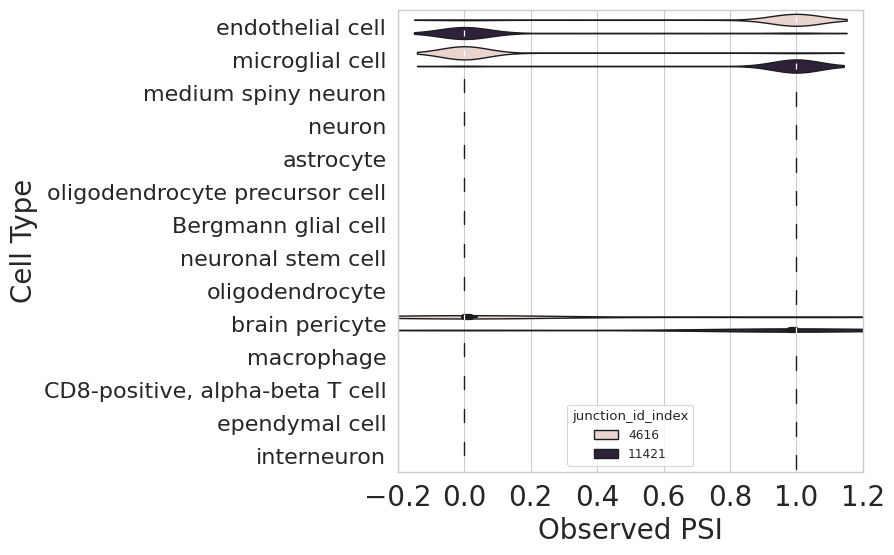

In [102]:
# if we have a prior for each junction we can see how much each factor varies from it 
vt.quick_clust_plot(1475, simple_data)

In [ ]:
# check some known genes from pachter paper 
# check how trends change across age 
# check if there is batch effect from sex or mouse id 
# try running on all cells from all ages together? 
# sort of have within cell normalization so should be fine? 